--- Task 1: Data Understanding ---
Success! Dataset Loaded. Total Rows: 50000

Sentiment Counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


C:\Users\Mohammed Saqib\AppData\Local\Temp\ipykernel_21640\358244778.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


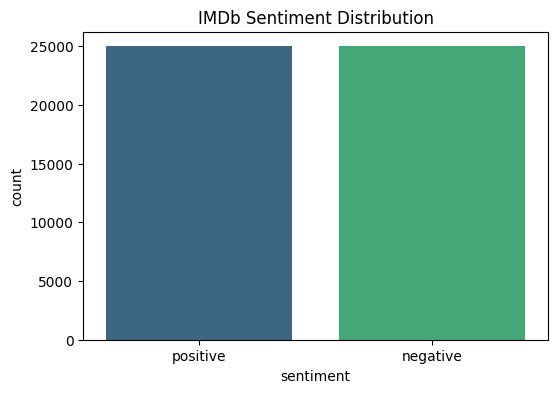


Sample Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...


In [7]:
import kagglehub
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Download the correct CSV-based dataset
print("Downloading the correct Sentiment Dataset...")
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

# 2. Find the CSV file in the new path
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("--- Task 1: Data Understanding ---")
print(f"Success! Dataset Loaded. Total Rows: {len(df)}")

# 3. Explore Class Distribution
print("\nSentiment Counts:")
print(df['sentiment'].value_counts())

# 4. Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('IMDb Sentiment Distribution')
plt.show()

# 5. Display sample text
print("\nSample Review:")
print(df['review'].iloc[0][:200] + "...")

In [8]:

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLP requirements
nltk.download('stopwords')
nltk.download('wordnet')

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Stopword removal
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if w not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)


# Apply to 5000 rows
df_small = df.sample(5000, random_state=42).copy()

print("Cleaning text... please wait.")
df_small['cleaned_review'] = df_small['review'].apply(preprocess_text)

print("--- Task 2 Complete ---")
print(df_small[['review', 'cleaned_review']].head())

[nltk_data] Downloading package stopwords to C:\Users\Mohammed
[nltk_data]     Saqib\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\Mohammed
[nltk_data]     Saqib\AppData\Roaming\nltk_data...


Cleaning text... please wait.
--- Task 2 Complete ---
                                                  review  \
33553  I really liked this Summerslam due to the look...   
9427   Not many television shows appeal to quite as m...   
199    The film quickly gets to a major chase scene w...   
12447  Jane Austen would definitely approve of this o...   
39489  Expectations were somewhat high for me when I ...   

                                          cleaned_review  
33553  really liked summerslam due look arena curtain...  
9427   many television show appeal quite many differe...  
199    film quickly get major chase scene ever increa...  
12447  jane austen would definitely approve one gwyne...  
39489  expectation somewhat high went see movie thoug...  


In [9]:

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. Initialize Bag of Words (CountVectorizer)
# We limit max_features to 5000 to keep the model efficient and prevent overfitting
bow_vectorizer = CountVectorizer(max_features=5000)

# 2. Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Prepare our X (input text) and y (target sentiment labels)
# Note: We use the 'cleaned_review' column we created in the previous step
X_text = df_small['cleaned_review']
y = df_small['sentiment'].apply(lambda x: 1 if x == 'positive' else 0) # Convert labels to numbers

# 3. Transform the text into numerical features
X_bow = bow_vectorizer.fit_transform(X_text)
X_tfidf = tfidf_vectorizer.fit_transform(X_text)

print("--- Task 3: Feature Engineering Complete ---")
print(f"Bag of Words Shape: {X_bow.shape}")
print(f"TF-IDF Shape:      {X_tfidf.shape}")

--- Task 3: Feature Engineering Complete ---
Bag of Words Shape: (5000, 5000)
TF-IDF Shape:      (5000, 5000)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Splitting the TF-IDF features (usually performs better than BoW)
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.20, random_state=42)

# Initialize the three required models
log_reg = LogisticRegression()
nb_classifier = MultinomialNB()
dt_classifier = DecisionTreeClassifier()

# Training the models
print("Training models... please wait.")
log_reg.fit(X_train, y_train)
nb_classifier.fit(X_train, y_train)
dt_classifier.fit(X_train, y_train)

print("--- Task 4: All 3 Models Trained Successfully ---")
     

Training models... please wait.
--- Task 4: All 3 Models Trained Successfully ---


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# List of our trained models and their names for easy iteration
models = {
    "Logistic Regression": log_reg,
    "Naive Bayes": nb_classifier,
    "Decision Tree": dt_classifier
}

# Dictionary to store results for Task 6 comparison
evaluation_results = {}

print("--- Task 5: Model Evaluation Metrics ---")

for name, model in models.items():
    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    evaluation_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    print(f"\nModel: {name}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("-" * 30)
    print(f"Detailed Classification Report for {name}:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

--- Task 5: Model Evaluation Metrics ---

Model: Logistic Regression
Accuracy:  0.8360
Precision: 0.8044
Recall:    0.8826
F1 Score:  0.8417
------------------------------
Detailed Classification Report for Logistic Regression:
              precision    recall  f1-score   support

    Negative       0.87      0.79      0.83       506
    Positive       0.80      0.88      0.84       494

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000


Model: Naive Bayes
Accuracy:  0.8370
Precision: 0.8357
Recall:    0.8340
F1 Score:  0.8349
------------------------------
Detailed Classification Report for Naive Bayes:
              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84       506
    Positive       0.84      0.83      0.83       494

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
we

In [12]:
import pandas as pd

# Convert the evaluation dictionary into a readable DataFrame
comparison_df = pd.DataFrame(evaluation_results).T

print("--- Model Performance Comparison Table ---")
display(comparison_df)

# Identify the best performing model based on F1 Score
best_model_name = comparison_df['F1 Score'].idxmax()
print(f"\nObservation: The {best_model_name} model achieved the highest F1-Score.")

--- Model Performance Comparison Table ---


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.836,0.804428,0.882591,0.841699
Naive Bayes,0.837,0.835700,0.834008,0.834853
Decision Tree,0.702,0.694444,0.708502,0.701403



Observation: The Logistic Regression model achieved the highest F1-Score.
